In [1]:
import os, sys
from pathlib import Path
import re
import h5py
import yaml
import matplotlib.pyplot as plt
import matplotlib as mtlb
import seaborn as sns
import pandas as pd
try:
    project_path = str(Path(__file__).parent.parent)
except Exception as e:
    print(f'{e}. Using os.getcwd() to resolve the project path.')
    project_path = str(Path(os.getcwd()).parent)

print(project_path)
if project_path not in sys.path:
    sys.path.append(project_path)
from utils.myems.myems.experiments import Experiment, flatten_dict






name '__file__' is not defined. Using os.getcwd() to resolve the project path.
c:\Users\juanf\OneDrive\Documents\GitHub\Compressive-spectral-imaging-using-graph-smoothness


params_variant_000_2756ce97.yaml 2756ce97 [WindowsPath('c:/Users/juanf/OneDrive/Documents/GitHub/Compressive-spectral-imaging-using-graph-smoothness/experiments/exp_0/outputs/simulated_data_HSDC2_DB_Oct112019_2_OE_2756ce97_v000.h5')]
params_variant_001_4bb58070.yaml 4bb58070 [WindowsPath('c:/Users/juanf/OneDrive/Documents/GitHub/Compressive-spectral-imaging-using-graph-smoothness/experiments/exp_0/outputs/simulated_data_HSDC2_DB_Oct112019_2_OE_4bb58070_v001.h5')]
params_variant_002_aa113550.yaml aa113550 [WindowsPath('c:/Users/juanf/OneDrive/Documents/GitHub/Compressive-spectral-imaging-using-graph-smoothness/experiments/exp_0/outputs/simulated_data_HSDC2_DB_Oct112019_2_OE_aa113550_v002.h5')]
params_variant_003_9223b90d.yaml 9223b90d [WindowsPath('c:/Users/juanf/OneDrive/Documents/GitHub/Compressive-spectral-imaging-using-graph-smoothness/experiments/exp_0/outputs/simulated_data_HSDC2_DB_Oct112019_2_OE_9223b90d_v003.h5')]


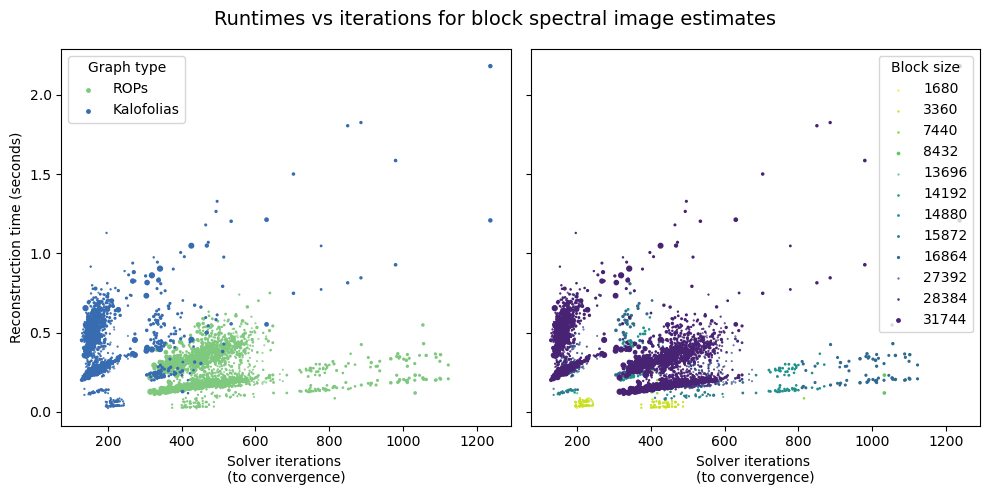


Graph: Kalofolias, Workers: 1
Total compute: 9366.89s
Real wallclock runtime: 9481.81s
Ideal parallel runtime: 9366.89s
Parallel efficiency: 98.79%
Overhead: 114.92s
Serial fraction: 1.21%
SAM :1.5e+01
PSNR :4.4e+01
SSIM :0.92

Graph: Kalofolias, Workers: 4
Total compute: 17859.73s
Real wallclock runtime: 4606.51s
Ideal parallel runtime: 4464.93s
Parallel efficiency: 96.93%
Overhead: 141.58s
Serial fraction: 3.07%
SAM :1.5e+01
PSNR :4.4e+01
SSIM :0.92

Graph: ROPs, Workers: 1
Total compute: 211.40s
Real wallclock runtime: 338.63s
Ideal parallel runtime: 211.40s
Parallel efficiency: 62.43%
Overhead: 127.24s
Serial fraction: 37.57%
SAM :1.7e+01
PSNR :4.4e+01
SSIM :0.91

Graph: ROPs, Workers: 4
Total compute: 433.80s
Real wallclock runtime: 176.79s
Ideal parallel runtime: 108.45s
Parallel efficiency: 61.34%
Overhead: 68.34s
Serial fraction: 38.66%
SAM :1.7e+01
PSNR :4.4e+01
SSIM :0.91


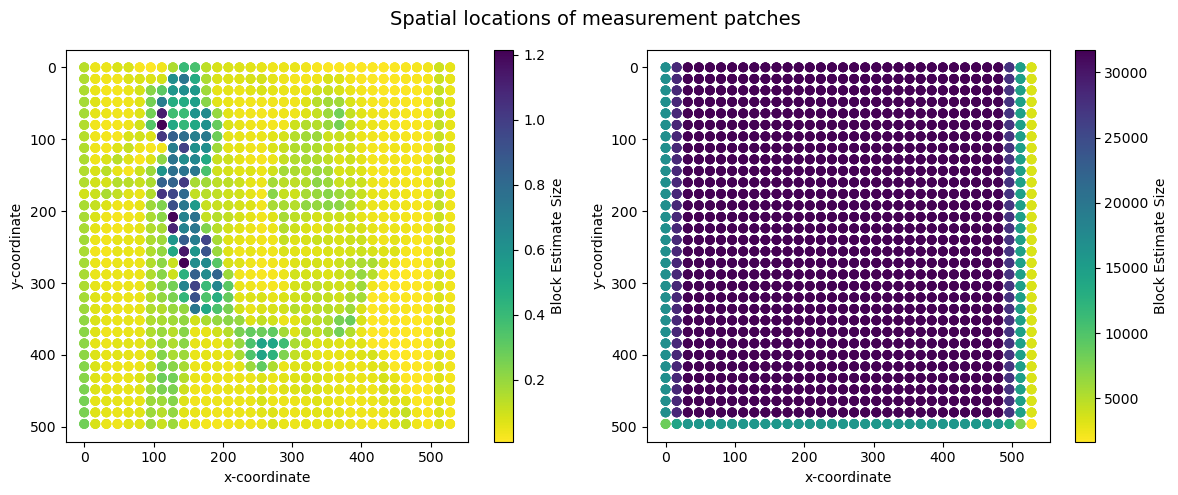

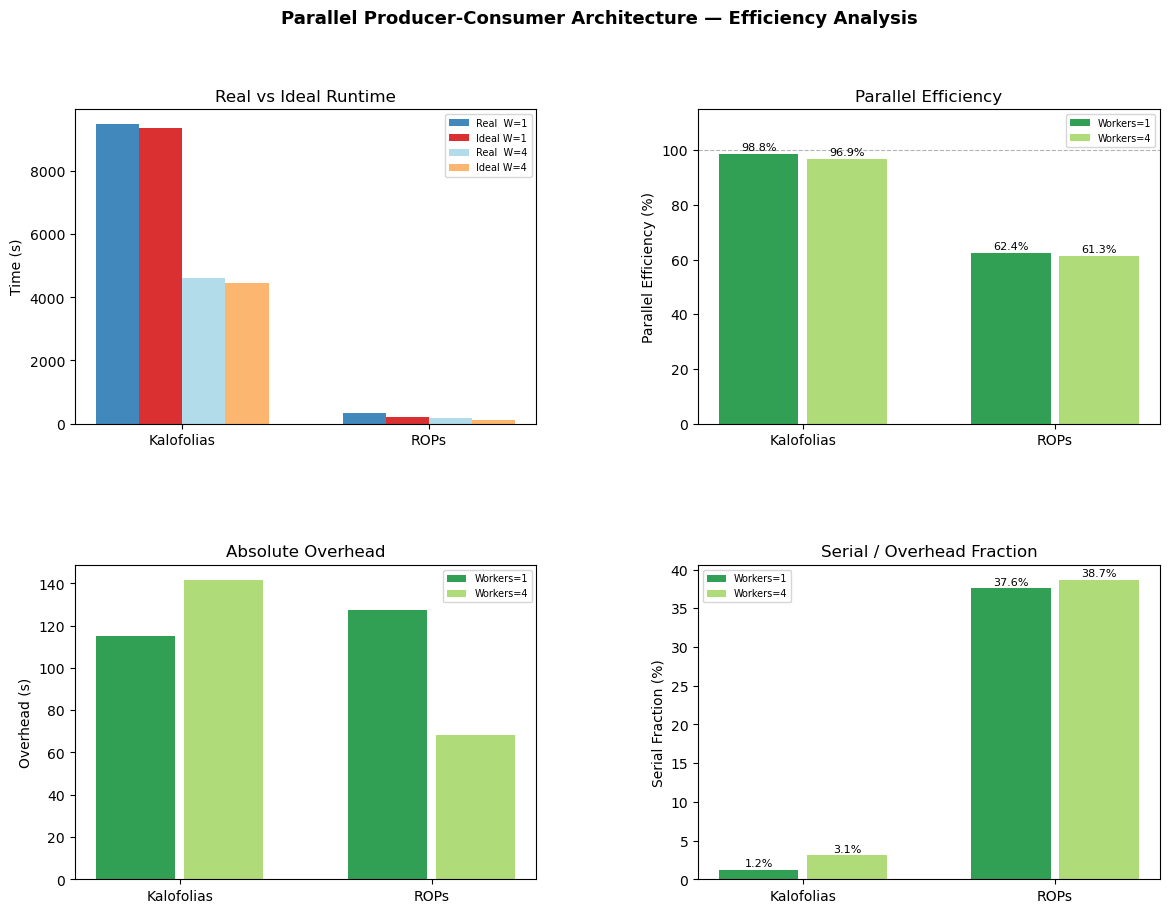

In [3]:
from experiments.exp_0_visualization import generate_figures, load_metadata, compute_mse
from experiments.exp_0_visualization import compute_parallel_efficiency_metrics, generate_parallel_efficiency_figure

# Analysis script
with Experiment(
    name="exp_0",  # Same name as computation experiment
    base_dir = os.path.join(project_path,'experiments'),
    params_baseline=None,  # Signal: analysis mode
    params_to_study=None
    ) as exp:

    # Load results from existing outputs
    #results = load_results(exp.outputs_dir)
    # Load metadata and metrics of block estimates
    files_to_analyze = ['simulated_data_HSDC2_DB_Oct112019_2_OE_2756ce97_v000.h5',
                        'simulated_data_HSDC2_DB_Oct112019_2_OE_4bb58070_v001.h5']



    df = load_metadata(exp.name, files_to_analyze = None)
    df = compute_mse(df).rename(columns={'block_size' : 'block_estimate_size'})
    #df = df.rename(columns={'block_size' : 'block_estimate_size'})
    figures = generate_figures(df)

    fig = generate_parallel_efficiency_figure(df)
    figures = figures + [fig]

    for fig in figures:
        exp.save_figure(fig.get('figure'),name=fig.get('name'),format='svg',dpi=400)


### Parallel efficiency analysis of block based reconstruction

params_variant_000_2756ce97.yaml 2756ce97 [WindowsPath('c:/Users/juanf/OneDrive/Documents/GitHub/Compressive-spectral-imaging-using-graph-smoothness/experiments/exp_0/outputs/simulated_data_HSDC2_DB_Oct112019_2_OE_2756ce97_v000.h5')]
params_variant_001_4bb58070.yaml 4bb58070 [WindowsPath('c:/Users/juanf/OneDrive/Documents/GitHub/Compressive-spectral-imaging-using-graph-smoothness/experiments/exp_0/outputs/simulated_data_HSDC2_DB_Oct112019_2_OE_4bb58070_v001.h5')]
params_variant_002_aa113550.yaml aa113550 [WindowsPath('c:/Users/juanf/OneDrive/Documents/GitHub/Compressive-spectral-imaging-using-graph-smoothness/experiments/exp_0/outputs/simulated_data_HSDC2_DB_Oct112019_2_OE_aa113550_v002.h5')]
params_variant_003_9223b90d.yaml 9223b90d [WindowsPath('c:/Users/juanf/OneDrive/Documents/GitHub/Compressive-spectral-imaging-using-graph-smoothness/experiments/exp_0/outputs/simulated_data_HSDC2_DB_Oct112019_2_OE_9223b90d_v003.h5')]
Index(['hash', 'params_file', 'output_file', 'dataset_file', 'su

In [6]:
df.groupby(['dataset_file', 'graph_graph_type', 'number_of_processors'])


Graph: Kalofolias, Workers: 1
Total compute: 9366.89s
Real wallclock runtime: 9481.81s
Ideal parallel runtime: 9366.89s
Parallel efficiency: 98.79%
Overhead: 114.92s
Serial fraction: 1.21%
SAM :1.5e+01
PSNR :4.4e+01
SSIM :0.92

Graph: Kalofolias, Workers: 4
Total compute: 17859.73s
Real wallclock runtime: 4606.51s
Ideal parallel runtime: 4464.93s
Parallel efficiency: 96.93%
Overhead: 141.58s
Serial fraction: 3.07%
SAM :1.5e+01
PSNR :4.4e+01
SSIM :0.92

Graph: ROPs, Workers: 1
Total compute: 211.40s
Real wallclock runtime: 338.63s
Ideal parallel runtime: 211.40s
Parallel efficiency: 62.43%
Overhead: 127.24s
Serial fraction: 37.57%
SAM :1.7e+01
PSNR :4.4e+01
SSIM :0.91

Graph: ROPs, Workers: 4
Total compute: 433.80s
Real wallclock runtime: 176.79s
Ideal parallel runtime: 108.45s
Parallel efficiency: 61.34%
Overhead: 68.34s
Serial fraction: 38.66%
SAM :1.7e+01
PSNR :4.4e+01
SSIM :0.91


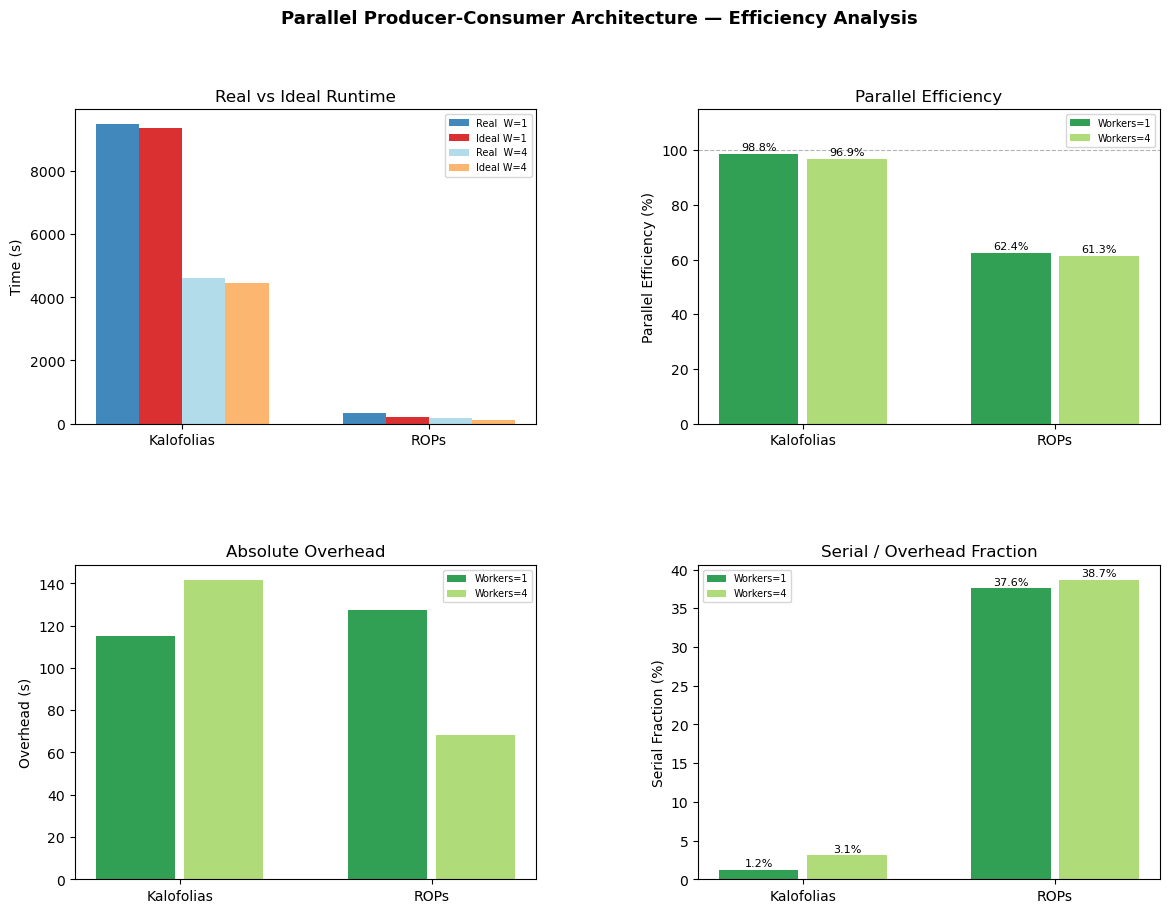

In [5]:

from exp_0_visualization import generate_parallel_efficiency_figure
fig = generate_parallel_efficiency_figure(results)

In [ ]:
graph_types = df.graph_graph_type.unique()
worker_pool_sizes = df.number_of_processors.unique()
variables_of_interest = ['dataset_file','output_file','group_name','number_of_blocks', 'aggregation_duration', 
                        'elpased_time_graph_inference', 
                        'elpased_time_signal_reconst','PSNR','SAM','SSIM']

#df.groupby(by=['dataset_file','graph_type','number_of_processors']).apply(compute_mse)

for sub_df in df.groupby(by=['dataset_file','graph_type','number_of_processors']).apply(compute_mse):
    sub_df = sub_df.copy()

    total_compute = (
        sub_df['elpased_time_graph_inference'] +
        sub_df['elpased_time_signal_reconst']
    ).sum()

    real_time = sub_df['aggregation_duration'].iloc[0]
    pool_size= sub_df['number_of_processors'].iloc[0]

    ideal_time = total_compute / pool_size
    parallel_efficiency = ideal_time/real_time
    overhead = real_time - ideal_time
    serial_fraction = overhead / real_time

    sam = sub_df['SAM'].iloc[0]
    ssim = sub_df['SSIM'].iloc[0]
    psnr = sub_df['PSNR'].iloc[0]

    print(f"\nGraph: {graph_type}, Workers: {pool_size}")
    print(f"Total compute: {total_compute:.2f}s")
    print(f"Real wallclock runtime: {real_time:.2f}s")
    print(f"Ideal parallel runtime: {ideal_time:.2f}s")
    print(f"Parallel efficiency: {parallel_efficiency:.2%}s")
    print(f"Overhead: {overhead:.2f}s")
    print(f"Serial fraction: {serial_fraction:.2%}")
    print(f"SAM :{sam:.2}")
    print(f"PSNR :{psnr:.2}")
    print(f"SSIM :{ssim:.2}")

for graph_type in graph_types:
    for pool_size in worker_pool_sizes:
        sub_df = df.loc[:,variables_of_interest]
        row_selector = (df.graph_graph_type==graph_type) & (df.number_of_processors==pool_size)
        sub_df = sub_df.loc[row_selector,:]
        #print(f"graph_type {graph_type}, pool_size {pool_size}")
        #print(sub_df.describe())
        #mse = []
        #for block_idx in range(sub_df.shape[0]):
        #    mse_block_idx = compute_mse(sub_df.iloc[block_idx,:])
        #    mse.append(mse_block_idx)
                # total compute time
        #sub_df['mse'] = mse
        sub_df = sub_df.copy()
        tmp = sub_df.apply(compute_mse, axis=1)
        sub_df['mse'] = [item[0] for item in tmp]
        sub_df['block_size'] = [item[1] for item in tmp]


        #plt.figure()
        #plt.hist(sub_df['mse'].dropna(), bins=30)
        #plt.xlabel("MSE")
        #plt.ylabel("Frequency")
        #plt.title("Histogram of MSE")
        #plt.show()

        total_compute = (
            sub_df['elpased_time_graph_inference'] +
            sub_df['elpased_time_signal_reconst']
        ).sum()

        real_time = sub_df['aggregation_duration'].iloc[0]
        ideal_time = total_compute / pool_size
        parallel_efficiency = ideal_time/real_time
        overhead = real_time - ideal_time
        serial_fraction = overhead / real_time

        sam = sub_df['SAM'].iloc[0]
        ssim = sub_df['SSIM'].iloc[0]
        psnr = sub_df['PSNR'].iloc[0]

        print(f"\nGraph: {graph_type}, Workers: {pool_size}")
        print(f"Total compute: {total_compute:.2f}s")
        print(f"Real wallclock runtime: {real_time:.2f}s")
        print(f"Ideal parallel runtime: {ideal_time:.2f}s")
        print(f"Parallel efficiency: {parallel_efficiency:.2%}s")
        print(f"Overhead: {overhead:.2f}s")
        print(f"Serial fraction: {serial_fraction:.2%}")
        print(f"SAM :{sam:.2}")
        print(f"PSNR :{psnr:.2}")
        print(f"SSIM :{ssim:.2}")



Graph: ROPs, Workers: 1
Total compute: 211.40s
Real wallclock runtime: 338.63s
Ideal parallel runtime: 211.40s
Parallel efficiency: 62.43%s
Overhead: 127.24s
Serial fraction: 37.57%
SAM :1.7e+01
PSNR :4.4e+01
SSIM :0.91

Graph: ROPs, Workers: 4
Total compute: 433.80s
Real wallclock runtime: 176.79s
Ideal parallel runtime: 108.45s
Parallel efficiency: 61.34%s
Overhead: 68.34s
Serial fraction: 38.66%
SAM :1.7e+01
PSNR :4.4e+01
SSIM :0.91

Graph: Kalofolias, Workers: 1
Total compute: 9366.89s
Real wallclock runtime: 9481.81s
Ideal parallel runtime: 9366.89s
Parallel efficiency: 98.79%s
Overhead: 114.92s
Serial fraction: 1.21%
SAM :1.5e+01
PSNR :4.4e+01
SSIM :0.92

Graph: Kalofolias, Workers: 4
Total compute: 17859.73s
Real wallclock runtime: 4606.51s
Ideal parallel runtime: 4464.93s
Parallel efficiency: 96.93%s
Overhead: 141.58s
Serial fraction: 3.07%
SAM :1.5e+01
PSNR :4.4e+01
SSIM :0.92


In [ ]:
df_copy = df.copy()

tmp = df_copy.apply(compute_mse, axis=1)

df_copy['mse'] = [item[0] for item in tmp]
df_copy['block_size'] = [item[1] for item in tmp]

df_copy = df_copy.sort_values(by=['dataset_file','graph_graph_type',
                                  'number_of_processors', 'elpased_time_signal_reconst','solver_info_num_iters','mse'], ascending=True)

df_copy.loc[:,['dataset_file','graph_graph_type',
               'number_of_processors','elpased_time_signal_reconst','solver_info_num_iters','solver_info_y_mean','solver_info_y_var','block_size','mse']].head()



0.0

In [34]:
top_difficult = df_copy.groupby(['dataset_file','number_of_processors']) \
                       .apply(lambda g: g.nlargest(int(len(g)*0.1), 'mse')) \
                       .reset_index(drop=True)

print(top_difficult.groupby(['dataset_file','number_of_processors','block_id'])['graph_graph_type'].nunique().value_counts())

graph_graph_type
1    154
2    140
Name: count, dtype: int64


C:\Users\juanf\AppData\Local\Temp\ipykernel_50464\1847433377.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(int(len(g)*0.1), 'mse')) \


C:\Users\juanf\AppData\Local\Temp\ipykernel_50464\2118206454.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(int(len(g)*0.5), 'mse')) \


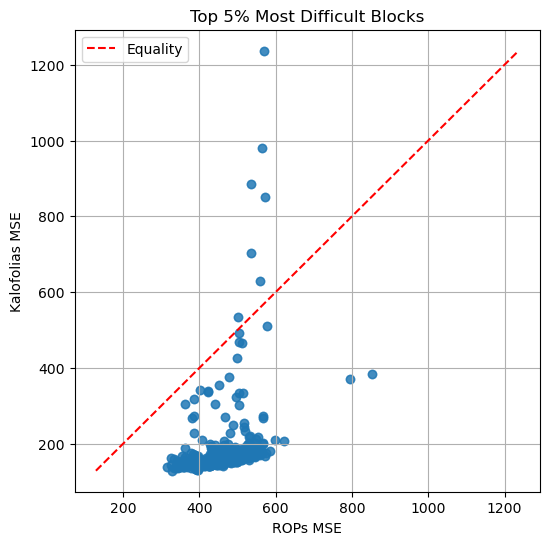

In [40]:
import matplotlib.pyplot as plt

#block_hardness = df_copy.solver_info_y_var * (1 + abs(df_copy.solver_info_y_mean))
#df_copy['block_hardness'] = (df_copy.block_size /( df_copy.block_height*df_copy.block_width)) * df_copy.solver_info_y_var * (1 + abs(df_copy.solver_info_y_mean))
# Select top 5% difficult blocks per dataset and processor count
top_difficult = df_copy.groupby(['dataset_file','number_of_processors']) \
                       .apply(lambda g: g.nlargest(int(len(g)*0.5), 'mse')) \
                       .reset_index(drop=True)

# Pivot so each row has both ROPs and Kalofolias MSE
pivot_df = top_difficult.pivot_table(index=['dataset_file','number_of_processors','block_id'],
                                     columns='graph_graph_type',
                                     #values='elpased_time_signal_reconst').dropna()
                                     values='solver_info_num_iters').dropna()#reset_index()
min_val = min(pivot_df['ROPs'].min(), pivot_df['Kalofolias'].min())
max_val = max(pivot_df['ROPs'].max(), pivot_df['Kalofolias'].max())



# Scatter plot: ROPs vs Kalofolias
plt.figure(figsize=(6,6))
plt.scatter(pivot_df['ROPs'], pivot_df['Kalofolias'], alpha=0.6)
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Equality')
plt.xlabel('ROPs MSE')
plt.ylabel('Kalofolias MSE')
plt.title('Top 5% Most Difficult Blocks')
plt.legend()
plt.grid(True)
plt.show()